In [23]:
import os

from dotenv import load_dotenv

load_dotenv(override=True)

# LangSmith 추적: API 키와 추적 on/off는 .env에서 읽고, 프로젝트 이름만 여기서 정한다
# (.env에 LANGSMITH_PROJECT가 있으면 그 값을 쓴다)
os.environ.setdefault("LANGSMITH_PROJECT", "SKALA-KVCACHE")
print("LangSmith 프로젝트:", os.environ["LANGSMITH_PROJECT"])

LangSmith 프로젝트: SKALA-KVCACHE


# Orchestrator-Workers (전문 워커 버전) — KV Cache 기술 평가

`orchestrator_workers.ipynb`(범용 워커 1종)와 같은 흐름이고, **워커만 관점별 전문 워커**로 바꾼 버전.

```
START → orchestrator → (Send) 전문 워커 × N → synthesizer → END
```

**워커 4종** — 기존 에이전트의 프롬프트(`prompts/*.txt`)와 평가 기준을 그대로 사용

| 워커 | 자료 | 역할 |
|---|---|---|
| `tech_research` | RAG + 대조 기술 RAG | 기술 개요, 적용 범위, 한계, TRL |
| `market_eval` | 웹검색 | 시장 규모·CAGR, 도입 기업 수, 생태계 |
| `stakeholder_eval` | RAG + 웹검색 | 경쟁사, 도입 기업/개발자, 투자업계 반응 |
| `domain_eval` | RAG + 웹검색 | 처리 가능 규모, 비용 절감 효과 |

**범용 워커 버전과의 차이**

| | 범용 워커 버전 | 전문 워커 버전 (이 노트북) |
|---|---|---|
| Orchestrator가 정하는 것 | 관점 이름, 지시, 사용할 자료까지 전부 | 어떤 워커를 **몇 번**, **어떻게 나눠**, **무엇에 집중해서** 부를지 |
| 평가 기준의 위치 | Orchestrator의 계획 프롬프트 | 워커별 프롬프트 (기존 파일 그대로) |
| 새 관점 추가 | 계획만으로 가능 | 워커 4종 범위 안에서만 가능 |
| 결과 형식 | 관점마다 자유 형식 | 워커별로 정해진 출력 형식 → 안정적 |

워커 종류는 고정이지만 **어떤 워커를 몇 개 띄울지는 계획이 정하므로** 고정 fan-out은 아님 (워커로 가는 고정 엣지 없음, `Send`로 분배).

## 1. 기본 구성

- LLM, 검색 도구, 프롬프트 파일은 기존 프로젝트 것을 재사용
- 프로젝트 루트에서 실행해야 함 (`prompts/`, `data/raw`, `.cache`가 상대 경로)

In [24]:
import operator
import uuid
from pathlib import Path
from typing import Annotated, List, Literal, Optional, TypedDict

from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_tavily import TavilySearch
from pydantic import BaseModel, Field

from agents.prompt_utils import rag_references, web_references, web_search
from rag.pdf import (
    format_docs,
    get_hw_comparison_retrieval_chain,
    get_sw_comparison_retrieval_chain,
    get_tech_retrieval_chain,
)

In [25]:
WORKER_MODEL = "gpt-5.6-luna"    # 워커 (기존 평가 에이전트와 동일)
PLANNER_MODEL = "gpt-5.6-terra"  # Orchestrator / Synthesizer

MAX_ATTEMPTS = 2  # task별 시도 상한 (종료 보장)

web_search_tool = TavilySearch(max_results=5)

## 2. STATE 정의

- 범용 워커 버전과 같은 구조. `Task`에 **어떤 워커가 처리할지(`worker`)** 가 들어가고, 자료 종류(`sources`)는 워커가 이미 알고 있으므로 빠짐
- **제어 / 결과 분리**: `tasks`(상태, 시도 횟수, 에러)와 `results`(본문, 출처)를 같은 `task_id`로 나눔
- **리듀서**: 병렬 워커가 동시에 쓰는 필드에는 모두 리듀서가 붙어 있고, 각 워커는 **자기 `task_id` 항목만** 반환

In [26]:
WorkerName = Literal["tech_research", "market_eval", "stakeholder_eval", "domain_eval"]
WORKERS = ["tech_research", "market_eval", "stakeholder_eval", "domain_eval"]


class Task(TypedDict, total=False):
    """제어 메타: 분배와 실패 대응 판단에 쓰는 정보."""

    task_id: str
    worker: WorkerName                        # 이 task를 처리할 전문 워커
    perspective: str                          # 화면/보고서에 쓸 짧은 이름
    instruction: str                          # 이번 조사에서 집중할 내용
    search_query: str                         # 검색에 쓸 짧은 키워드
    target: Optional[Literal["sw", "hw"]]     # 특정 기술만 다루면 지정
    status: Literal["pending", "done", "failed", "excluded"]
    attempts: int
    error: Optional[str]                      # 실패/부분 실패 사유


class TaskResult(TypedDict):
    """페이로드: 워커 결과물."""

    content: str
    references: List[str]


class Decision(TypedDict):
    """결정 1건과 그 사유 (관측성)."""

    node: str                                 # 결정을 내린 노드
    action: Literal["plan", "retry", "continue", "exclude"]
    task_ids: List[str]
    reason: str


def merge_tasks(left: dict, right: dict) -> dict:
    merged = dict(left)
    for task_id, patch in right.items():
        merged[task_id] = {**merged.get(task_id, {}), **patch}
    return merged


def merge_results(left: dict, right: dict) -> dict:
    return {**left, **right}


class GraphState(TypedDict):
    # 입력
    tech_sw: str
    tech_hw: str
    domain: str
    # 제어
    run_id: str                                               # 체크포인트 thread_id / 트레이스 태그와 공유
    tasks: Annotated[dict, merge_tasks]                       # task_id -> Task
    decisions: Annotated[List[Decision], operator.add]
    # 결과
    results: Annotated[dict, merge_results]                   # task_id -> TaskResult
    synthesis: str


class WorkerInput(TypedDict):
    # Send로 각 워커에 전달되는 개별 입력 (전체 State가 아님)
    task: Task
    tech_sw: str
    tech_hw: str
    domain: str

## 3. 계획 스키마

- Orchestrator의 구조화 출력. `worker`는 등록된 4종 중에서만 고를 수 있음
- `task_id`, `status`, `attempts` 같은 제어 값은 LLM이 아니라 코드가 붙임

In [27]:
class PlannedTask(BaseModel):
    worker: WorkerName = Field(description="이 task를 처리할 워커")
    perspective: str = Field(description="task를 구분할 짧은 이름 (예: '시장성 - HW', '도메인 - 비용')")
    instruction: str = Field(description="이번 조사에서 특히 집중할 내용 1~3문장")
    search_query: str = Field(description="검색에 쓸 핵심 키워드. 기술명을 포함해 100자 이내")
    target: Optional[Literal["sw", "hw"]] = Field(
        description="한쪽 기술만 다루면 'sw' 또는 'hw', 두 기술을 함께 다루면 null. "
        "tech_research는 반드시 지정"
    )


class Plan(BaseModel):
    tasks: List[PlannedTask] = Field(description="서로 독립적으로 병렬 수행 가능한 task 목록")
    reason: str = Field(description="이렇게 계획한 이유 1~2문장")

## 4. Orchestrator 노드

- 실행 **전에 한 번** LLM이 전체 평가를 task N개로 나누고, task마다 **어떤 전문 워커가 맡을지** 지정
- 같은 워커를 여러 번 부를 수 있음 (예: 시장 평가를 SW / HW로 나누기, 도메인 평가를 규모 / 비용으로 나누기)
- 평가 기준 자체는 워커 프롬프트에 있으므로, Orchestrator는 **분할 방식과 집중할 내용**을 정함
- 계획 생성 자체가 실패하면 기본 계획으로 대체하고, 그 사실을 `decisions`에 기록

In [28]:
planner_llm = init_chat_model(PLANNER_MODEL, model_provider="openai", temperature=0)
planner = planner_llm.with_structured_output(Plan)

PLAN_PROMPT = """당신은 KV cache 최적화 기술 평가를 조율하는 Orchestrator입니다.
아래 두 기술을 평가하기 위해, 서로 '독립적으로' 병렬 수행할 수 있는 task로 분해하고
task마다 담당 워커를 지정하세요.

- SW 기술: {tech_sw}
- HW 기술: {tech_hw}
- 평가 도메인: {domain}

[사용 가능한 워커]
- tech_research: 원문 논문에서 기술 개요, 적용 범위, 한계, 기술성숙도(TRL)를 추출. 한 번에 한 기술만 처리(target 필수)
- market_eval: 웹검색으로 시장 규모·CAGR, 도입 기업 수·발표 빈도, 생태계 지지를 조사
- stakeholder_eval: 원문과 웹검색으로 경쟁사 포지셔닝, 도입 기업/개발자 반응, 투자업계 시각을 조사
- domain_eval: 원문과 웹검색으로 {domain}에서의 처리 가능 규모, 비용 절감 효과(TCO, 에너지 효율)를 조사

[규칙]
- tech_research는 SW, HW 각각 1개씩 반드시 포함하세요.
- market_eval, stakeholder_eval, domain_eval은 각각 최소 1개 포함하세요.
- 한 관점이 SW와 HW에서 성격이 크게 다르거나, 한 번의 검색으로 다루기에 범위가 넓으면
  같은 워커의 task를 여러 개로 나누세요 (target으로 나누거나, 집중할 내용으로 나누기).
- instruction에는 두 기술의 성격을 고려해 그 task에서 특히 확인해야 할 점을 쓰세요.
- task는 5~9개, 다른 task의 결과에 의존하지 않아야 합니다."""

# 계획 생성이 실패했을 때 쓰는 기본 계획
DEFAULT_PLAN = [
    {"worker": "tech_research", "perspective": "기술 조사 - SW", "target": "sw",
     "instruction": "기술 개요, 적용 범위, 한계, 기술성숙도 근거를 정리한다.",
     "search_query": "{tech_sw}"},
    {"worker": "tech_research", "perspective": "기술 조사 - HW", "target": "hw",
     "instruction": "기술 개요, 적용 범위, 한계, 기술성숙도 근거를 정리한다.",
     "search_query": "{tech_hw}"},
    {"worker": "market_eval", "perspective": "시장성", "target": None,
     "instruction": "두 기술의 시장성과 채택 현황을 비교한다.",
     "search_query": "{tech_sw} {tech_hw} 시장 규모 CAGR 채택 사례"},
    {"worker": "stakeholder_eval", "perspective": "이해관계자", "target": None,
     "instruction": "경쟁사, 도입 기업/개발자, 투자업계 반응을 정리한다.",
     "search_query": "{tech_sw} {tech_hw} 경쟁사 대응 도입 사례 투자 동향"},
    {"worker": "domain_eval", "perspective": "도메인 적합성", "target": None,
     "instruction": "처리 가능한 규모와 비용 절감 효과를 평가한다.",
     "search_query": "{tech_sw} {tech_hw} {domain} scalability TCO energy efficiency"},
]

In [29]:
def _split_tech_research(planned: list[dict]) -> list[dict]:
    """tech_research는 한 번에 한 기술만 처리하므로, target이 없으면 SW/HW 두 task로 나눈다."""
    normalized = []
    for task in planned:
        if task["worker"] == "tech_research" and task.get("target") is None:
            for target in ("sw", "hw"):
                normalized.append({**task, "target": target,
                                   "perspective": f"{task['perspective']} - {target.upper()}"})
        else:
            normalized.append(task)
    return normalized


def orchestrator(state: GraphState):
    names = {"tech_sw": state["tech_sw"], "tech_hw": state["tech_hw"], "domain": state["domain"]}
    try:
        plan = planner.invoke(PLAN_PROMPT.format(**names))
        planned = [task.model_dump() for task in plan.tasks]
        if not planned:
            raise ValueError("빈 계획")
        reason = plan.reason
    except Exception as e:
        planned = [
            {**task, "instruction": task["instruction"].format(**names),
             "search_query": task["search_query"].format(**names)}
            for task in DEFAULT_PLAN
        ]
        reason = f"계획 생성 실패({e})로 기본 계획 사용"

    # task_id, status 같은 제어 값은 코드가 붙인다. task_id는 "워커명-순번"
    tasks: dict = {}
    counts: dict = {}
    for task in _split_tech_research(planned):
        counts[task["worker"]] = counts.get(task["worker"], 0) + 1
        task_id = f"{task['worker']}-{counts[task['worker']]}"
        tasks[task_id] = {**task, "task_id": task_id, "status": "pending",
                          "attempts": 0, "error": None}

    print(f"🧩 계획된 task {len(tasks)}개: {reason}")
    for task_id, task in tasks.items():
        print(f"   {task_id}: {task['perspective']} (target={task['target']})")

    return {
        "tasks": tasks,
        "decisions": [{"node": "orchestrator", "action": "plan",
                       "task_ids": list(tasks), "reason": reason}],
    }

## 5. Worker 노드

### 5-1. 공통 부분

- **프롬프트**: 기존 `prompts/*.txt`를 그대로 읽고, 끝에 Orchestrator의 지시를 받는 `{instruction}` 자리만 덧붙임
- **자료 수집 헬퍼**: `search_rag`, `search_web`은 실패해도 예외를 내지 않고 `(본문, 출처, 에러)`를 반환
- **재시도 (Fall-back 1)**: `run_with_retry`가 워커의 1회 실행 함수를 `MAX_ATTEMPTS`까지 다시 시도하고, 반환 형식을 통일
  - 출력은 **자기 `task_id` 항목만** 담은 `tasks`, `results`
  - 끝까지 실패하면 `status: "failed"`로 반환 (제외 여부는 Synthesizer가 판정)

In [30]:
INSTRUCTION_SUFFIX = """

[이번 조사에서 집중할 내용]
{instruction}
"""


def load_worker_prompt(path: str) -> PromptTemplate:
    """기존 프롬프트 파일에 Orchestrator 지시 자리를 덧붙인다."""
    return PromptTemplate.from_template(Path(path).read_text(encoding="utf-8") + INSTRUCTION_SUFFIX)


worker_llm = init_chat_model(WORKER_MODEL, model_provider="openai", temperature=0)

tech_research_chain = load_worker_prompt("prompts/tech_research.txt") | worker_llm | StrOutputParser()
market_chain = load_worker_prompt("prompts/market_eval.txt") | worker_llm | StrOutputParser()
stakeholder_chain = load_worker_prompt("prompts/stakeholder_eval.txt") | worker_llm | StrOutputParser()
domain_chain = load_worker_prompt("prompts/domain_eval.txt") | worker_llm | StrOutputParser()

In [31]:
def search_rag(get_chain, query: str, label: str = "RAG"):
    """RAG 검색. (본문, 출처, 에러)를 반환하고 실패 시 본문은 빈 문자열이다."""
    try:
        docs = get_chain().retriever.invoke(query)
        return format_docs(docs), rag_references(docs), None
    except Exception as e:
        return "", [], f"{label} 검색 실패: {e}"


def search_web(query: str):
    """웹검색. 제목/URL/본문만 골라 정리한다. 결과가 없으면 본문은 빈 문자열이다."""
    found = web_search(web_search_tool, query[:300])  # Tavily 쿼리 길이 제한 대비
    if not found.get("results"):
        return "", [], "웹검색 결과 없음"
    text = "\n\n".join(
        f"<web><title>{item.get('title')}</title><url>{item.get('url')}</url>"
        f"<content>{item.get('content')}</content></web>"
        for item in found["results"]
    )
    return text, web_references(found), None


def join_errors(*errors) -> Optional[str]:
    return "; ".join(e for e in errors if e) or None


def run_with_retry(state: WorkerInput, run_once, node: str):
    """run_once(state) -> (content, references, error)를 MAX_ATTEMPTS까지 시도한다.
    content가 None이거나 예외가 나면 실패로 본다."""
    task_id = state["task"]["task_id"]
    decisions: list[Decision] = []

    for attempt in range(1, MAX_ATTEMPTS + 1):
        try:
            content, references, error = run_once(state)
        except Exception as e:
            content, references, error = None, [], f"{type(e).__name__}: {e}"
        if content is not None:
            return {
                "tasks": {task_id: {"status": "done", "attempts": attempt, "error": error}},
                "results": {task_id: {"content": content,
                                      "references": list(dict.fromkeys(references))}},
                "decisions": decisions,
            }
        if attempt < MAX_ATTEMPTS:
            decisions.append({"node": node, "action": "retry", "task_ids": [task_id],
                              "reason": f"{attempt}회 실패({error}), 재시도"})

    return {
        "tasks": {task_id: {"status": "failed", "attempts": MAX_ATTEMPTS, "error": error}},
        "decisions": decisions,
    }

### 5-2. 전문 워커 4종

- 워커마다 **쓰는 자료와 프롬프트가 고정**되어 있고, task에서 받는 것은 검색어와 집중할 내용뿐
- 자료를 여러 종류 쓰는 워커는 일부만 실패하면 남은 자료로 진행하고 `error`에 사유를 남김. 필요한 자료가 하나도 없으면 실패

In [32]:
def _tech_research_once(state: WorkerInput):
    """원문 RAG + 대조 기술 RAG. 원문이 없으면 실패."""
    task = state["task"]
    is_sw = task.get("target") != "hw"
    tech_name = state["tech_sw"] if is_sw else state["tech_hw"]

    chunks, refs, error = search_rag(get_tech_retrieval_chain, tech_name)
    if not chunks:
        return None, [], error

    get_comparison = get_sw_comparison_retrieval_chain if is_sw else get_hw_comparison_retrieval_chain
    comparison, comparison_refs, comparison_error = search_rag(
        get_comparison, "핵심 아이디어와 구조적 접근 방식", label="대조 기술 RAG"
    )
    content = tech_research_chain.invoke(
        {
            "tech_name": tech_name,
            "retrieved_chunks": chunks,
            "comparison_chunks": comparison,
            "instruction": task["instruction"],
        }
    )
    return content, refs + comparison_refs, join_errors(error, comparison_error)


def _market_once(state: WorkerInput):
    """웹검색만 사용. 검색 결과가 없으면 실패."""
    task = state["task"]
    web, refs, error = search_web(task["search_query"])
    if not web:
        return None, [], error
    content = market_chain.invoke(
        {
            "tech_sw": state["tech_sw"],
            "tech_hw": state["tech_hw"],
            "search_results": web,
            "instruction": task["instruction"],
        }
    )
    return content, refs, error


def _rag_and_web_once(state: WorkerInput, chain, extra_inputs: dict):
    """원문 RAG + 웹검색을 함께 쓰는 워커의 공통 흐름. 둘 다 없으면 실패."""
    task = state["task"]
    chunks, rag_refs, rag_error = search_rag(get_tech_retrieval_chain, task["search_query"])
    web, web_refs, web_error = search_web(task["search_query"])
    error = join_errors(rag_error, web_error)
    if not chunks and not web:
        return None, [], error
    content = chain.invoke(
        {
            "tech_sw": state["tech_sw"],
            "tech_hw": state["tech_hw"],
            "retrieved_chunks": chunks,
            "search_results": web,
            "supplement_search_results": "",
            "instruction": task["instruction"],
            **extra_inputs,
        }
    )
    return content, rag_refs + web_refs, error


def _stakeholder_once(state: WorkerInput):
    return _rag_and_web_once(state, stakeholder_chain, {})


def _domain_once(state: WorkerInput):
    return _rag_and_web_once(state, domain_chain, {"domain": state["domain"]})

In [33]:
# 그래프에 등록할 노드 함수 (이름은 Task.worker 값과 일치해야 함)
def tech_research(state: WorkerInput):
    return run_with_retry(state, _tech_research_once, "tech_research")


def market_eval(state: WorkerInput):
    return run_with_retry(state, _market_once, "market_eval")


def stakeholder_eval(state: WorkerInput):
    return run_with_retry(state, _stakeholder_once, "stakeholder_eval")


def domain_eval(state: WorkerInput):
    return run_with_retry(state, _domain_once, "domain_eval")

## 6. Fan-out 라우팅

- 계획된 task마다 **task에 적힌 워커**로 `Send` → 같은 워커가 여러 개 뜰 수도, 하나만 뜰 수도 있음
- 워커로 가는 **고정 엣지가 없음**. 어떤 워커가 몇 개 뜰지는 계획(State)을 읽어 결정 → Dynamic Fan-out

In [34]:
from langgraph.types import Send

In [35]:
def assign_workers(state: GraphState):
    return [
        Send(
            task["worker"],
            {"task": task, "tech_sw": state["tech_sw"], "tech_hw": state["tech_hw"],
             "domain": state["domain"]},
        )
        for task in state["tasks"].values()
    ]

## 7. Synthesizer 노드

- `results`에 누적된 워커 결과를 집계. task 개수가 실행마다 달라지므로 고정 자리 없이 **목록으로** 넣음
- **계속 / 제외 (Fall-back 2)**: 워커가 끝까지 실패한 task는 `excluded`로 바꿔 집계에서 빼고, 일부 자료만 실패한 task는 결과를 그대로 써서 계속 진행. 두 경우 모두 사유를 `decisions`에 기록하고 **자료 한계**로 전달

In [36]:
synth_prompt = ChatPromptTemplate.from_template(
    """아래는 여러 워커가 병렬로 조사한 관점별 결과입니다.
기술 성숙도, 시장성, 이해관계자, 도메인 적용 관점의 결과를 읽고, 우열을 판정하지 말고
관점 간 "일치하는 지점"과 "상충하는 지점"을 중심으로 종합하세요.

- SW 기술: {tech_sw}
- HW 기술: {tech_hw}
- 평가 도메인: {domain}

[관점별 조사 결과]
{joined}

[자료 한계]
{limitations}

[출력 형식]
- 일치하는 지점: ...
- 상충하는 지점: ...
- 관점별 결론 요약(병렬 서술, 우열 판정 금지): ...
- 자료 한계: (위 [자료 한계]에 있는 항목만. 없으면 "없음")"""
)
synth_llm = init_chat_model(PLANNER_MODEL, model_provider="openai", temperature=0)
synth_chain = synth_prompt | synth_llm | StrOutputParser()


def collect_limitations(tasks: dict) -> list[str]:
    """제외되었거나 일부 자료가 실패한 task를 보고서 한계점 재료로 뽑는다."""
    return [
        f"{task['perspective']} ({'제외' if task['status'] == 'excluded' else '일부 자료 실패'}): "
        f"{task['error']}"
        for task in tasks.values()
        if task.get("error")
    ]


def collect_references(state: GraphState) -> list[str]:
    """종합에 쓰인 task들의 출처를 순서 유지 + 중복 제거해서 모은다."""
    refs = [
        ref
        for task_id, result in state["results"].items()
        if state["tasks"][task_id]["status"] == "done"
        for ref in result["references"]
    ]
    return list(dict.fromkeys(refs))

In [37]:
def synthesizer(state: GraphState):
    # --- Fall-back 판정: 실패한 task는 제외, 일부 자료만 실패한 task는 계속 ---
    updates: dict = {}
    decisions: list[Decision] = []
    for task_id, task in state["tasks"].items():
        if task["status"] == "failed":
            updates[task_id] = {"status": "excluded"}
            decisions.append({"node": "synthesizer", "action": "exclude", "task_ids": [task_id],
                              "reason": f"{task['attempts']}회 시도 후 결과 없음({task['error']})"})
        elif task.get("error"):
            decisions.append({"node": "synthesizer", "action": "continue", "task_ids": [task_id],
                              "reason": f"일부 자료 실패, 남은 자료로 계속({task['error']})"})
    tasks = merge_tasks(state["tasks"], updates)

    joined = "\n\n".join(
        f"### [{task['worker']}] {task['perspective']}\n{state['results'][task_id]['content']}"
        for task_id, task in tasks.items()
        if task["status"] == "done"
    )
    limitations = collect_limitations(tasks)
    synthesis = synth_chain.invoke(
        {
            "tech_sw": state["tech_sw"],
            "tech_hw": state["tech_hw"],
            "domain": state["domain"],
            "joined": joined or "(조사 결과 없음)",
            "limitations": "\n".join(f"- {item}" for item in limitations) or "없음",
        }
    )
    return {"synthesis": synthesis, "tasks": updates, "decisions": decisions}

## 8. Graph 구성

- `orchestrator → (Send) 전문 워커 × N → synthesizer` : 워커가 모두 끝나면 Synthesizer가 한 번 실행
- 워커 노드 4개를 등록해 두지만, 실제로 어떤 노드가 몇 번 실행될지는 `assign_workers`가 계획을 읽어 결정
- **종료 보장**: 그래프에 되돌아가는 엣지가 없고, 워커 내부 재시도는 `MAX_ATTEMPTS`로 제한됨
- **재개/상관**: 체크포인터를 붙이고 `run_id`를 `thread_id`와 LangSmith 추적의 이름·태그·메타데이터로 함께 사용

In [38]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

In [39]:
WORKER_NODES = {
    "tech_research": tech_research,
    "market_eval": market_eval,
    "stakeholder_eval": stakeholder_eval,
    "domain_eval": domain_eval,
}

builder = StateGraph(GraphState)

builder.add_node("orchestrator", orchestrator)
for name, node in WORKER_NODES.items():
    builder.add_node(name, node)
builder.add_node("synthesizer", synthesizer)

builder.add_edge(START, "orchestrator")
# 조건부 엣지가 Send 리스트를 반환 -> 계획에 적힌 워커들로 병렬 fan-out
builder.add_conditional_edges("orchestrator", assign_workers, WORKERS)
for name in WORKER_NODES:
    builder.add_edge(name, "synthesizer")
builder.add_edge("synthesizer", END)

graph = builder.compile(checkpointer=MemorySaver())

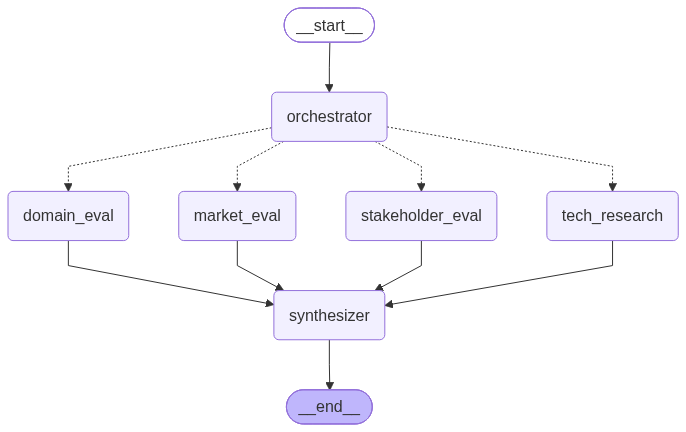

In [40]:
try:
    display(Image(graph.get_graph().draw_mermaid_png(max_retries=3, retry_delay=2.0)))
except Exception as e:
    # 그림은 외부 서비스(mermaid.ink)로 렌더링하므로 네트워크 상태에 따라 실패할 수 있다.
    # 그래프는 이미 컴파일되어 있어 아래 셀 실행에는 영향이 없고, 대신 mermaid 코드를 출력한다
    # (https://mermaid.live 에 붙여 넣으면 그림으로 볼 수 있다).
    print(f"그래프 이미지 렌더링 실패: {type(e).__name__}\n")
    print(graph.get_graph().draw_mermaid())

## 9. 실행

Orchestrator가 평가를 task로 분해하고 워커를 지정 → 전문 워커들이 병렬 조사 → Synthesizer가 하나로 집계하는 흐름 확인.

- 처음 실행하면 `.cache/chroma_index` 인덱스를 열고, 목록에 없는 출처는 정리하고 새 PDF만 임베딩함

In [41]:
run_id = uuid.uuid4().hex[:12]
# run_id를 체크포인트 thread_id와 LangSmith 추적(이름, 태그, 메타데이터)에 함께 사용
config = {
    "configurable": {"thread_id": run_id},
    "run_name": f"kv-cache-eval-specialized-{run_id}",
    "tags": ["orchestrator-workers", "specialized-workers", f"run:{run_id}"],
    "metadata": {"run_id": run_id},
}

result = graph.invoke(
    {
        "tech_sw": "DeepSeek-V2 (MLA)",
        "tech_hw": "ITME (Inference Tiered Memory Expansion)",
        "domain": "데이터센터/클라우드 서빙",
        "run_id": run_id,
        "tasks": {},
        "results": {},
        "decisions": [],
    },
    config=config,
)

print("\n===== 평가 종합 =====\n")
print(result["synthesis"])

🧩 계획된 task 8개: SW 알고리즘인 MLA와 HW/시스템 인프라인 ITME는 기술 원리·시장·이해관계자·서빙 경제성의 검증 근거와 비교군이 달라, 각 관점을 기술별로 분리했습니다. 모든 과제는 독립적으로 조사 가능하며, 기술성·시장성·이해관계자·도메인 효과를 병렬로 포괄합니다.
   tech_research-1: 기술성 - MLA (target=sw)
   tech_research-2: 기술성 - ITME (target=hw)
   market_eval-1: 시장성 - MLA 생태계 (target=sw)
   market_eval-2: 시장성 - ITME 인프라 (target=hw)
   stakeholder_eval-1: 이해관계자 - MLA 경쟁 (target=sw)
   stakeholder_eval-2: 이해관계자 - ITME 경쟁 (target=hw)
   domain_eval-1: 도메인 효과 - MLA 서빙 (target=sw)
   domain_eval-2: 도메인 효과 - ITME 서빙 (target=hw)

===== 평가 종합 =====

- **일치하는 지점:**
  1. **문제 정의의 공통성:** MLA와 ITME 모두 데이터센터/클라우드 LLM 서빙에서 장문 컨텍스트, 높은 동시성, 멀티턴·에이전트형 워크로드로 인해 커지는 **KV cache 메모리 병목**을 핵심 대상으로 본다.
  2. **기술 계층의 차이와 보완성:**  
     - MLA는 attention 구조에서 KV를 latent 표현으로 압축해 **필요 KV cache 총량 자체를 줄이는 모델·소프트웨어 기술**이다.  
     - ITME는 HBM·호스트 DRAM·CXL 하이브리드 메모리·SSD·원격 계층을 활용해 **남아 있는 모델 상태와 KV cache의 수용 용량을 확장하는 하드웨어·시스템 기술**이다.  
     다수 관점은 두 기술을 직접 대체재보다는 결합 가능한 보완재로 해석한다.
  3. **결합 아키텍처의 방향:** 활성 상태와 지연시간 민

## 10. 결과 확인

State만 보고 **무엇을 계획했고, 왜 그렇게 결정했고, 어떻게 끝났는지** 확인.

In [42]:
def show_run(state: GraphState):
    print(f"run_id={state['run_id']}\n")
    print("[결정 로그]")
    for d in state["decisions"]:
        print(f"  {d['node']:<16} {d['action']:<8} {d['task_ids']} - {d['reason']}")
    print("\n[task 상태]")
    for task_id, task in state["tasks"].items():
        print(f"  {task_id:<19} {task['status']:<8} 시도 {task['attempts']} {task['perspective']}"
              + (f"  ! {task['error']}" if task.get("error") else ""))
    print("\n[자료 한계]")
    for item in collect_limitations(state["tasks"]) or ["없음"]:
        print(f"  - {item}")


show_run(result)

print("\n[참고 자료]")
for ref in collect_references(result):
    print(f"  - {ref}")

run_id=63e3ac082ae4

[결정 로그]
  orchestrator     plan     ['tech_research-1', 'tech_research-2', 'market_eval-1', 'market_eval-2', 'stakeholder_eval-1', 'stakeholder_eval-2', 'domain_eval-1', 'domain_eval-2'] - SW 알고리즘인 MLA와 HW/시스템 인프라인 ITME는 기술 원리·시장·이해관계자·서빙 경제성의 검증 근거와 비교군이 달라, 각 관점을 기술별로 분리했습니다. 모든 과제는 독립적으로 조사 가능하며, 기술성·시장성·이해관계자·도메인 효과를 병렬로 포괄합니다.

[task 상태]
  tech_research-1     done     시도 1 기술성 - MLA
  tech_research-2     done     시도 1 기술성 - ITME
  market_eval-1       done     시도 1 시장성 - MLA 생태계
  market_eval-2       done     시도 1 시장성 - ITME 인프라
  stakeholder_eval-1  done     시도 1 이해관계자 - MLA 경쟁
  stakeholder_eval-2  done     시도 1 이해관계자 - ITME 경쟁
  domain_eval-1       done     시도 1 도메인 효과 - MLA 서빙
  domain_eval-2       done     시도 1 도메인 효과 - ITME 서빙

[자료 한계]
  - 없음

[참고 자료]
  - data/raw/DeepSeek-V2.pdf (p.1)
  - data/raw/TransMLA_MLA_Is_All_You_Need.pdf (p.2)
  - data/raw/DeepSeek-V2.pdf (p.20)
  - data/raw/SGLang_v0.3_Release_7x_ Faster_DeepSeek MLA, 1.5x Faster torch.compile,

## 11. Fall-back 동작 확인

웹검색이 실패하는 상황을 만들어, 실패한 task가 **재시도 → 제외**로 처리되고도 그래프가 끝까지 도는지 확인.

- `market_eval`: 웹검색만 쓰므로 재시도 후에도 실패 → Synthesizer가 `excluded` 처리
- `stakeholder_eval`, `domain_eval`: RAG 자료로 결과를 만들고 `error`에 "웹검색 결과 없음"만 기록 (계속)
- `tech_research`: 웹검색을 쓰지 않으므로 영향 없음

In [ ]:
class BrokenSearch:
    """항상 실패하는 웹검색 도구 (fall-back 확인용)."""

    def invoke(self, _):
        raise RuntimeError("웹검색 장애 (테스트)")


original_tool = web_search_tool
web_search_tool = BrokenSearch()
try:
    fail_run_id = uuid.uuid4().hex[:12]
    failed_result = graph.invoke(
        {
            "tech_sw": "DeepSeek-V2 (MLA)",
            "tech_hw": "ITME (Inference Tiered Memory Expansion)",
            "domain": "데이터센터/클라우드 서빙",
            "run_id": fail_run_id,
            "tasks": {},
            "results": {},
            "decisions": [],
        },
        config={
            "configurable": {"thread_id": fail_run_id},
            "run_name": f"kv-cache-eval-specialized-fallback-{fail_run_id}",
            "tags": ["orchestrator-workers", "specialized-workers", "fallback-test",
                     f"run:{fail_run_id}"],
            "metadata": {"run_id": fail_run_id},
        },
    )
finally:
    web_search_tool = original_tool

show_run(failed_result)

🧩 계획된 task 8개: MLA는 모델·소프트웨어 알고리즘이고 ITME는 메모리 계층 하드웨어이므로, 동일 평가 관점에서도 근거 स्रोत·핵심 지표·제약이 다릅니다. 이에 기술성, 시장성, 이해관계자, 데이터센터 서빙 효과를 기술별로 분리해 8개 독립 작업으로 병렬화했습니다.
   tech_research-1: 기술성 - SW MLA (target=sw)
   tech_research-2: 기술성 - HW ITME (target=hw)
   market_eval-1: 시장성 - SW KV 압축 (target=sw)
   market_eval-2: 시장성 - HW 메모리 확장 (target=hw)
   stakeholder_eval-1: 이해관계자 - MLA (target=sw)
   stakeholder_eval-2: 이해관계자 - ITME (target=hw)
   domain_eval-1: 도메인 효과 - MLA 서빙 (target=sw)
   domain_eval-2: 도메인 효과 - ITME 서빙 (target=hw)
[WARN] 웹검색 실패 (MLA KV cache compression LLM inference market CAGR vLLM SGLang support): 웹검색 장애 (테스트)
[WARN] 웹검색 실패 (MLA KV cache compression LLM inference market CAGR vLLM SGLang support): 웹검색 장애 (테스트)
[WARN] 웹검색 실패 (AI inference tiered memory expansion CXL market CAGR data center adoption): 웹검색 장애 (테스트)
[WARN] 웹검색 실패 (AI inference tiered memory expansion CXL market CAGR data center adoption): 웹검색 장애 (테스트)
[WARN] 웹검색 실패 (ITME Inference Tiered Memory Expansion CXL compe

## 12. 보고서 생성 + 품질 평가 Loop

Synthesizer 뒤에 기존 프로젝트의 **보고서 생성**(`agents/report_gen.py`, `prompts/report_gen.txt`)을 붙이고, 그 뒤에 **품질 평가 노드**를 추가. 평가에 미달하면 피드백을 들고 보고서 생성으로 되돌아감.

```
… → synthesizer → report_gen → quality_eval ─(통과)→ END
                      ↑             │
                      └──(미달)─────┘   최대 MAX_REVISIONS번 재작성
```

- 앞 구간(orchestrator → 워커 → synthesizer)은 **Orchestrator-Workers**, 이 구간은 **Evaluator-Optimizer** 패턴
- 앞에서 만든 노드와 State는 그대로 쓰고, State에 필드 3개만 추가

### 12-1. State 확장

- `report`: 최신 보고서 본문 (재작성하면 덮어씀)
- `review`: **최신 평가 1건** (덮어씀 → 누적되지 않음). 평가 이력은 `decisions`에 한 줄씩 남음
- `revision`: 보고서 작성 횟수 → Loop 종료 보장용
- `decisions`의 `action`에 `accept`(통과) / `revise`(재작성) / `stop`(미달인 채 종료) 가 추가로 쓰임

In [ ]:
MAX_REVISIONS = 2  # 보고서 재작성 상한 (최초 작성 1회 + 재작성 최대 2회)


class CriterionResult(TypedDict):
    name: str        # 평가 항목
    passed: bool
    comment: str     # 판정 근거 / 미달 사유


class ReportReview(TypedDict):
    passed: bool                       # 모든 항목 통과 여부
    criteria: List[CriterionResult]
    feedback: str                      # 재작성 시 보고서 생성에 넘길 수정 지시
    error: Optional[str]               # 평가 자체가 실패한 경우의 사유


class ReportState(GraphState):
    report: str
    review: ReportReview
    revision: int

### 12-2. 보고서 생성 노드

- 기존 `prompts/report_gen.txt`를 그대로 사용. 프롬프트의 고정 자리(`{market_eval}` 등)에는 **같은 워커의 task 결과를 묶어서** 넣음 (워커가 여러 번 불렸으면 소제목으로 구분)
- `자료 부족 노드`에는 제외되었거나 일부 자료가 실패한 task를, `실제 참고 자료 목록`에는 종합에 쓰인 task의 출처를 중복 제거해서 넣음
- 재작성일 때는 프롬프트 끝에 **이전 보고서와 평가 피드백**을 덧붙임
- 기존 `outputs/report.md`를 덮어쓰지 않도록 다른 파일명으로 저장

In [ ]:
REPORT_PATH = "outputs/report_orchestrator_workers.md"

REVISION_SUFFIX = """

[이전 보고서]
{previous_report}

[품질 평가 피드백]
{feedback}
위 피드백이 "없음"이 아니면, 이전 보고서에서 지적된 항목을 모두 고쳐 보고서 전체를 다시 작성하세요.
지적되지 않은 부분은 유지하고, 위 [출력 형식]과 근거 사용 규칙은 그대로 지키세요.
"""

report_prompt = PromptTemplate.from_template(
    Path("prompts/report_gen.txt").read_text(encoding="utf-8") + REVISION_SUFFIX
)
report_llm = init_chat_model(PLANNER_MODEL, model_provider="openai", temperature=0)
report_chain = report_prompt | report_llm | StrOutputParser()


def results_of(state: GraphState, worker: str, target: Optional[str] = None) -> str:
    """한 워커(필요하면 한 기술)가 만든 결과들을 묶어 프롬프트의 고정 자리에 넣을 문자열로 만든다."""
    parts = [
        f"#### {task['perspective']}\n{state['results'][task_id]['content']}"
        for task_id, task in state["tasks"].items()
        if task["worker"] == worker
        and task["status"] == "done"
        and (target is None or task.get("target") == target)
    ]
    return "\n\n".join(parts) or "근거 부족 (조사 결과 없음)"


def report_inputs(state: GraphState) -> dict:
    """보고서와 품질 평가가 함께 쓰는 근거 자료."""
    limitations = collect_limitations(state["tasks"])
    references = collect_references(state)
    return {
        "tech_sw": state["tech_sw"],
        "tech_hw": state["tech_hw"],
        "domain": state["domain"],
        "tech_research_sw": results_of(state, "tech_research", "sw"),
        "tech_research_hw": results_of(state, "tech_research", "hw"),
        "market_eval": results_of(state, "market_eval"),
        "stakeholder_eval": results_of(state, "stakeholder_eval"),
        "domain_eval": results_of(state, "domain_eval"),
        "synthesis": state.get("synthesis", ""),
        "data_limited": "\n".join(f"- {item}" for item in limitations) or "없음",
        "references": "\n".join(f"- {ref}" for ref in references) or "없음",
    }


def report_gen(state: ReportState):
    revision = state.get("revision", 0) + 1
    review = state.get("review") or {}
    print(f"\n==== [REPORT GEN] {revision}번째 작성 ====")

    report = report_chain.invoke(
        {
            **report_inputs(state),
            "previous_report": state.get("report") or "없음",
            "feedback": review.get("feedback") or "없음",
        }
    )

    os.makedirs("outputs", exist_ok=True)
    Path(REPORT_PATH).write_text(report, encoding="utf-8")
    print(f"{REPORT_PATH} 저장 완료")
    return {"report": report, "revision": revision}

### 12-3. 품질 평가 노드

평가 항목은 과제의 평가 항목 목록을 받지 못해 `prompts/report_gen.txt`의 요구사항에서 뽑은 **임시 항목**. 과제 항목이 정해지면 `LLM_CRITERIA`와 코드 검사를 그에 맞게 바꾸면 됨.

| 항목 | 방식 | 기준 |
|---|---|---|
| 구성 완결성 | 코드 | SUMMARY, 1~6장, REFERENCE 제목이 모두 있는가 |
| 출처 정합성 | 코드 | 보고서에 나온 URL이 모두 실제 참고 자료 목록에 있는가 (지어낸 출처 없음) |
| 근거 충실성 | LLM | 보고서의 수치·기업명·사례가 워커 조사 결과에 있는가 |
| 관점 포괄성 | LLM | 기술 성숙도, 시장, 이해관계자, 도메인 관점이 모두 다뤄졌는가 |
| 한계점 반영 | LLM | 자료 부족 항목이 한계점에 반영됐는가 |
| 요약 적절성 | LLM | SUMMARY가 반 페이지 이내의 요약문인가 |

- 기계적으로 확인할 수 있는 것은 **코드로 검사** (LLM 판정보다 확실함)
- 하나라도 미달이면 미달 사유를 모아 `feedback`으로 만들고 보고서 생성으로 되돌림

In [ ]:
import re

REQUIRED_SECTIONS = ["SUMMARY", "1. 분석 배경", "2. 기술 선정", "3. 기술 개요",
                     "4. 관점별 평가", "5. 시사점", "6. 한계점", "REFERENCE"]
URL_PATTERN = re.compile(r"https?://[^\s)>\]]+")


def _urls(text: str) -> set:
    return {url.rstrip(".,;") for url in URL_PATTERN.findall(text)}


def check_structure(report: str) -> CriterionResult:
    headings = [line for line in report.splitlines() if line.lstrip().startswith("#")]
    missing = [s for s in REQUIRED_SECTIONS if not any(s in h for h in headings)]
    return {"name": "구성 완결성", "passed": not missing,
            "comment": f"누락된 장: {', '.join(missing)}" if missing else "필수 장이 모두 있음"}


def check_references(report: str, references: list[str]) -> CriterionResult:
    unknown = sorted(_urls(report) - _urls("\n".join(references)))
    return {"name": "출처 정합성", "passed": not unknown,
            "comment": f"참고 자료 목록에 없는 URL: {', '.join(unknown)}" if unknown
            else "모든 URL이 참고 자료 목록에 있음"}

In [ ]:
LLM_CRITERIA = {
    "근거 충실성": "보고서에 나온 수치, 기업명, 사례가 [근거 자료]에 실제로 있는가. "
                 "근거 자료에 없는 수치나 사례가 하나라도 있으면 미달",
    "관점 포괄성": "기술 성숙도, 시장, 이해관계자, 도메인 관점이 '4. 관점별 평가'에서 모두 다뤄졌는가. "
                 "조사 결과가 없는 관점은 '근거 부족'으로 명시했으면 통과",
    "한계점 반영": "[자료 한계]의 항목이 '6. 한계점'에 반영되었는가. 자료 한계가 '없음'이면 통과",
    "요약 적절성": "SUMMARY가 반 페이지(약 600자) 이내이고, 목차 나열이 아니라 핵심 결론을 담은 요약문인가",
}


class CriterionJudgement(BaseModel):
    name: Literal["근거 충실성", "관점 포괄성", "한계점 반영", "요약 적절성"]
    passed: bool = Field(description="기준을 충족하면 true")
    comment: str = Field(description="판정 근거. 미달이면 어느 부분을 어떻게 고쳐야 하는지 구체적으로")


class ReviewOutput(BaseModel):
    criteria: List[CriterionJudgement] = Field(description="네 항목 각각에 대한 판정")


review_prompt = ChatPromptTemplate.from_template(
    """당신은 기술 평가 보고서의 품질을 검수하는 평가자입니다.
아래 [보고서]를 [근거 자료]와 대조해, [평가 항목] 네 가지를 각각 판정하세요.
보고서를 고쳐 쓰지 말고 판정과 사유만 내세요. 엄격하게 판정하되, 사유는 보고서의 구체적인 부분을 짚으세요.

[평가 항목]
{criteria}

[근거 자료 - 워커 조사 결과]
### 기술 조사(SW)
{tech_research_sw}

### 기술 조사(HW)
{tech_research_hw}

### 시장 평가
{market_eval}

### 이해관계자 평가
{stakeholder_eval}

### 도메인 평가
{domain_eval}

### 평가 종합
{synthesis}

[자료 한계]
{data_limited}

[보고서]
{report}"""
)
review_llm = init_chat_model(PLANNER_MODEL, model_provider="openai", temperature=0)
reviewer = review_prompt | review_llm.with_structured_output(ReviewOutput)

In [ ]:
def quality_eval(state: ReportState):
    revision = state["revision"]
    report = state["report"]
    print(f"\n==== [QUALITY EVAL] {revision}번째 보고서 ====")

    # 1. 코드로 확인할 수 있는 항목
    criteria: list[CriterionResult] = [
        check_structure(report),
        check_references(report, collect_references(state)),
    ]

    # 2. LLM이 판정하는 항목
    error = None
    try:
        inputs = {k: v for k, v in report_inputs(state).items() if k != "references"}
        output = reviewer.invoke(
            {
                **inputs,
                "report": report,
                "criteria": "\n".join(f"- {name}: {rule}" for name, rule in LLM_CRITERIA.items()),
            }
        )
        judged = {c.name: c for c in output.criteria}
        for name in LLM_CRITERIA:
            if name in judged:
                criteria.append({"name": name, "passed": judged[name].passed,
                                 "comment": judged[name].comment})
            else:  # 평가자가 빠뜨린 항목은 통과로 치지 않는다
                criteria.append({"name": name, "passed": False, "comment": "평가 결과 누락"})
    except Exception as e:
        error = f"평가 LLM 호출 실패: {e}"

    failed = [c for c in criteria if not c["passed"]]
    passed = not failed and error is None
    review: ReportReview = {
        "passed": passed,
        "criteria": criteria,
        "feedback": "\n".join(f"- [{c['name']}] {c['comment']}" for c in failed),
        "error": error,
    }

    for c in criteria:
        print(f"  {'통과' if c['passed'] else '미달'}  {c['name']}: {c['comment']}")

    # 3. 다음 행동 결정 (라우팅 함수는 이 결과를 그대로 따른다)
    failed_names = ", ".join(c["name"] for c in failed)
    if passed:
        action, reason = "accept", f"{revision}번째 보고서가 모든 항목 통과"
    elif error:
        action, reason = "stop", f"{error} → 평가할 수 없어 현재 보고서로 종료"
    elif revision > MAX_REVISIONS:
        action, reason = "stop", f"재작성 상한({MAX_REVISIONS}회) 도달, 미달 항목: {failed_names}"
    else:
        action, reason = "revise", f"미달 항목: {failed_names}"
    print(f"  → {action}: {reason}")

    return {
        "review": review,
        "decisions": [{"node": "quality_eval", "action": action, "task_ids": [], "reason": reason}],
    }


def route_after_review(state: ReportState):
    """quality_eval이 남긴 마지막 결정에 따라 재작성(report_gen) 또는 종료."""
    return "report_gen" if state["decisions"][-1]["action"] == "revise" else END

### 12-4. Graph 구성

- 앞에서 만든 노드(orchestrator, 워커 4종, synthesizer)를 그대로 등록하고 `report_gen`, `quality_eval`만 추가
- **종료 보장**: 되돌아가는 엣지는 `quality_eval → report_gen` 하나뿐이고, `revision`이 `MAX_REVISIONS`를 넘으면 미달이어도 종료. 미달인 채 끝났다는 사실은 `review`와 `decisions`에 남음

In [ ]:
full_builder = StateGraph(ReportState)

full_builder.add_node("orchestrator", orchestrator)
for name, node in WORKER_NODES.items():
    full_builder.add_node(name, node)
full_builder.add_node("synthesizer", synthesizer)
full_builder.add_node("report_gen", report_gen)
full_builder.add_node("quality_eval", quality_eval)

full_builder.add_edge(START, "orchestrator")
full_builder.add_conditional_edges("orchestrator", assign_workers, WORKERS)
for name in WORKER_NODES:
    full_builder.add_edge(name, "synthesizer")
full_builder.add_edge("synthesizer", "report_gen")
full_builder.add_edge("report_gen", "quality_eval")
# 평가 통과/상한 도달이면 종료, 미달이면 보고서 재작성
full_builder.add_conditional_edges("quality_eval", route_after_review, ["report_gen", END])

full_graph = full_builder.compile(checkpointer=MemorySaver())

In [ ]:
try:
    display(Image(full_graph.get_graph().draw_mermaid_png(max_retries=3, retry_delay=2.0)))
except Exception as e:
    print(f"그래프 이미지 렌더링 실패: {type(e).__name__}\n")
    print(full_graph.get_graph().draw_mermaid())

### 12-5. 실행

계획 → 워커 병렬 조사 → 종합 → 보고서 → 품질 평가(미달 시 재작성)까지 한 번에 실행.

- 앞의 9번 실행과는 별개의 새 실행이라 계획부터 다시 수행함 (LLM·검색 호출이 다시 발생)

In [ ]:
full_run_id = uuid.uuid4().hex[:12]
full_config = {
    "configurable": {"thread_id": full_run_id},
    "run_name": f"kv-cache-eval-report-{full_run_id}",
    "tags": ["orchestrator-workers", "specialized-workers", "quality-loop", f"run:{full_run_id}"],
    "metadata": {"run_id": full_run_id},
}

full_result = full_graph.invoke(
    {
        "tech_sw": "DeepSeek-V2 (MLA)",
        "tech_hw": "ITME (Inference Tiered Memory Expansion)",
        "domain": "데이터센터/클라우드 서빙",
        "run_id": full_run_id,
        "tasks": {},
        "results": {},
        "decisions": [],
        "revision": 0,
    },
    config=full_config,
)

### 12-6. 결과 확인

품질 평가가 몇 번 돌았고, 어떤 항목 때문에 재작성했는지, 최종 보고서가 통과했는지 확인.

In [ ]:
show_run(full_result)

review = full_result["review"]
print(f"\n[품질 평가] 보고서 {full_result['revision']}회 작성, 최종 판정: "
      f"{'통과' if review['passed'] else '미달'}"
      + (f" ({review['error']})" if review.get("error") else ""))
for c in review["criteria"]:
    print(f"  {'통과' if c['passed'] else '미달'}  {c['name']}: {c['comment']}")

print(f"\n===== 최종 보고서 ({REPORT_PATH}) =====\n")
print(full_result["report"])

-> LangSmith Tracing

- 프로젝트 `SKALA-KVCACHE`에서 `kv-cache-eval-specialized-<run_id>` 실행을 열면 orchestrator → 전문 워커 × N → synthesizer 흐름과 각 워커의 검색·LLM 호출을 확인할 수 있음
- 12번의 전체 실행은 `kv-cache-eval-report-<run_id>` 이름과 `quality-loop` 태그로 남고, 보고서 재작성이 일어났으면 `report_gen` → `quality_eval`이 반복된 것이 보임
- `specialized-workers` 태그로 범용 워커 버전의 실행과 구분됨

## 다음 단계

노트북에서 확인한 구조를 프로젝트 코드로 옮길 때 남은 작업:

- 품질 평가 항목을 과제의 평가 항목으로 교체 (지금은 임시 항목)
- 노드별로 파일 분리 (`agents/orchestrator.py`, `agents/quality_eval.py`, 기존 `agents/*.py`를 워커 형태로 변경, `graph/state.py`, `graph/build_graph.py`)
- 프롬프트 파일에 `{instruction}`, `{feedback}` 자리를 직접 넣기 (지금은 노트북에서 덧붙임)
- 체크포인터를 `MemorySaver`에서 디스크 기반(`SqliteSaver`, `langgraph-checkpoint-sqlite` 설치 필요)으로 교체해 프로세스가 죽어도 재개 가능하게

---
End of Documents